<a href="https://colab.research.google.com/github/marcos-henestrosa/PAS_Procesos_estoc-sticos/blob/main/PAS_Marcos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***PASEO ALEATORIO SIMPLE***

En este documento realizaré varias gráficas con simulaciones de un ejemplo específico de proceso estocástico, llamado paseo aleatorio simple (PAS).
En primer lugar, un proceso estocástico se define como una familia de variables aleatorias $\{X_t\}_{t \in T}$ , donde el conjunto T es arbitrario.

 En particular, el PAS se define de la siguiente manera: consideramos en primer lugar el proceso estocástico $\{Z_n\}_{n \in \mathbb{N}}$, donde las variables $Z_n$ son independientes e idénticamente distribuidas; y $P(Z_n = 1) = p$, $P(Z_n = -1) =1-p$

De esa manera, el PAS de parámetro p se define como $X_n = \sum_{t=1}^{n} Z_t$

Intuitivamente, cada observación de un PAS de parámetro p representa una posible  trayectoria de una partícula que se despalaza hacia arriba con probabilidad $p$ y hacia abajo con probabilidad $1-p$

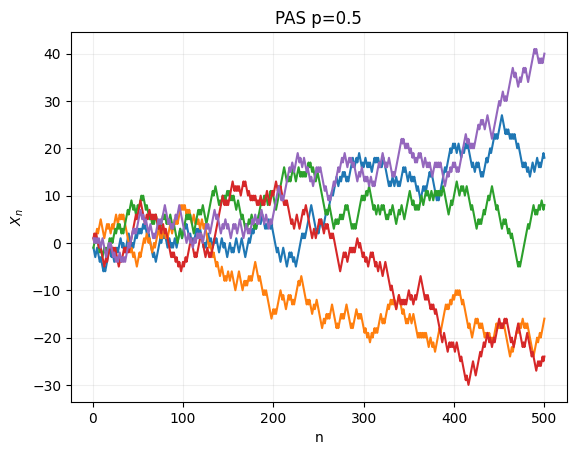

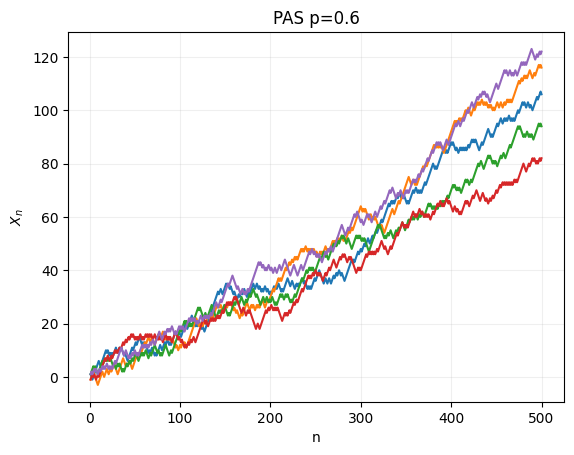

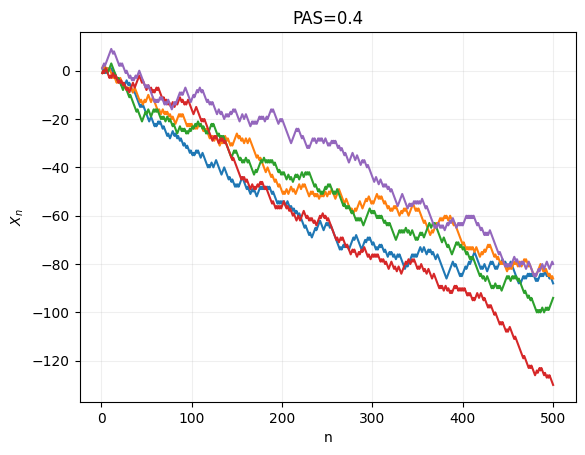

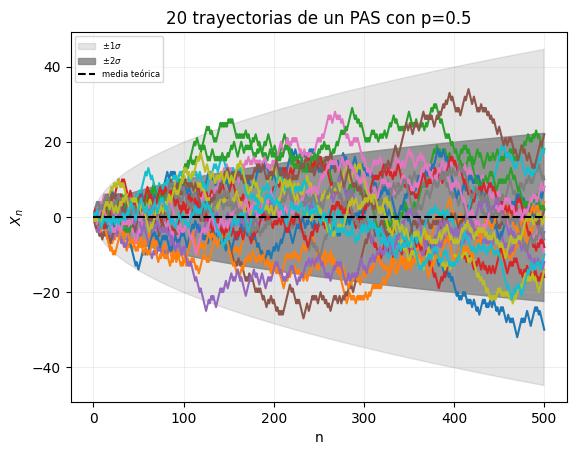

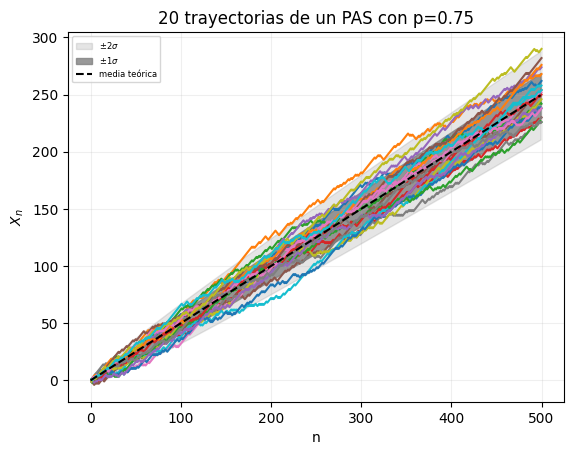

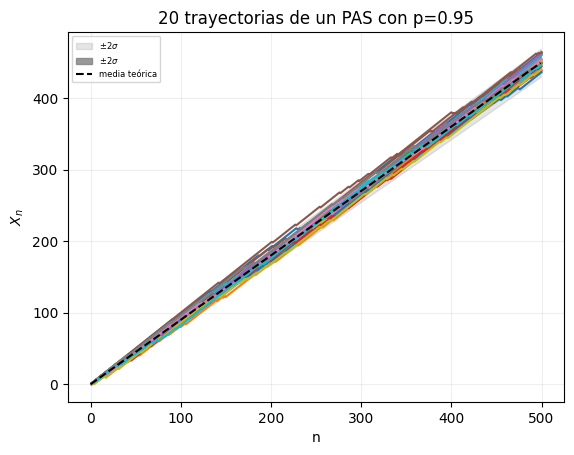

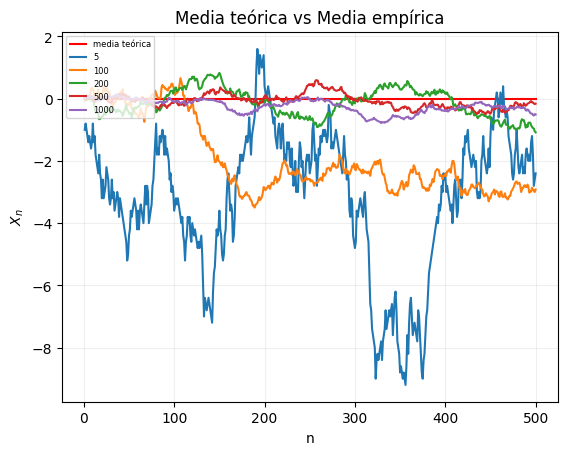

In [ ]:
import numpy as np
from matplotlib import pyplot as plt





"""
En primer lugar, queremos elaborar tres gráficas en la que respectivamente simulamos 5 trayectorias de un PAS de parámetros p=0.5, p=0.6 y p=0.7.
En el eje Y represento la posición y en el eje X los pasos (representaré solo los 500 primeros pasos)
"""

#Defino una función a la que se le aporten el valor del parámetro "p", el número de pasos "n" y la cantidad de trayectorias que se quieren simular "reps".

def simular_PAS(p,n,reps=1):
  a=[1,-1]
  k=[p,1-p]
  z=np.random.choice(a,(reps,n),p=k)  #Matriz de unos y menos unos. Tiene tantas filas como trayectorias y tantas columas como pasos (de ahí la dimensión (reps,n)).
                                            #Cada fila representa una trayectoria y cada elemento, 1 o -1, representa si en cada paso se sube o se baja.
  np.cumsum(z,axis=1,out=z)           #Calculamos las sumas acumuladas de los valores de cada fila. De esa manera, la función nos devuelve una matriz con las posiciones
                                            #finales en cada paso de cada trayectoria.
  return z



#Dibujamos las tres gráficas:

reps=5
n=500
for i in range(0,reps):       #Con un for dibujo las trayectorias una a una.
  y=simular_PAS(0.5,n)        #Aquí "y" es una matriz 1xn.
  y=np.ravel(y)               #La convierto en un vector de tamaño n para poder dibujar la trayectoria.
  x=np.arange(1,n+1)
  plt.plot(x,y)

#Completo la gráfica
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.grid(alpha=0.2)
plt.title('PAS p=0.5')
plt.show()



#Igual para p=0.6

for i in range(0,reps):
  y=simular_PAS(0.6,n)
  y=np.ravel(y)
  x=np.arange(1,n+1)
  plt.plot(x,y)

plt.xlabel('n')
plt.ylabel('$X_n$')
plt.grid(alpha=0.2)
plt.title('PAS p=0.6')
plt.show()


#Igual para p=0.4

for i in range(0,reps):
  y=simular_PAS(0.4,n)
  y=np.ravel(y)
  x=np.arange(1,n+1)
  plt.plot(x,y)

plt.xlabel('n')
plt.ylabel('$X_n$')
plt.grid(alpha=0.2)
plt.title('PAS=0.4')
plt.show()





"""
Puede ser interesante dibujar las mismas gráficas, pero que en este caso aparezcan también la media teórica y un entorno alrededor
de la media teórica de longitud +-1, +-2 las desviaciones típicas teóricas. Ahora consideraremos 20 trayectorias en vez de 5. Por la desigualdad
de Chebyshev, la probabilidad de que cada variable aleatoria X_n tome un valor en el interior de la banda "media teórica +-2 la desviación típica", es, de al
menos, 0.75.
"""


reps=20
p=0.5

#Dibujamos las trayectorias:
for i in range (0,reps):
  y=simular_PAS(p,n)
  y=np.ravel(y)
  x=np.arange(1,n+1)
  plt.plot(x,y)


#Creamos las bandas y la media teórica

c=np.arange(0,n)           #Vector de abcisas.

media_th=(2*p-1)*c         #Se puede comprobar fácilmente, a partir de la definición del PAS como sumatoria, que la esperanza de X_n es (2p-1)*n
                                 #(pues la esperanza de Z_n es 2p-1). Este vector media_th contiene las medias teóricas de cada X_n.
sigma=np.sqrt(4*p*(1-p)*c) #De una forma análoga se tiene que la varianza de Z_n es 4p(1-p)*n (pues la varianza de Z_n es 4p(1-p)).
                                #La esperanza y varianza de Z_n se puede calcular directamente o bien usando que cada Z_n sigue una distribución 2X-1, donde X es una
                                #binomial de parámetros (1,p). Este vector sigma contiene las desviaciones típicas teóricas de cada X_n.

#Creamos las bandas con la siguiente función:
plt.fill_between(c,
                 media_th - 2*sigma,
                 media_th + 2*sigma,
                 color='gray',
                 alpha=0.2,
                 label=(r'$\pm 1 \sigma$'))

plt.fill_between(c,
                 media_th - sigma,
                 media_th + sigma,
                 color='gray',
                 alpha=0.8, label=(r'$\pm 2 \sigma$'))

#Dibujamos la media teórica con líneas discontinuas:
plt.plot(c,media_th,'--k', label=('media teórica'))

#Completamos la gráfica:
plt.title('20 trayectorias de un PAS con p=0.5')
plt.legend(loc='upper left',fontsize=6)
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.grid(alpha=0.2)

plt.show()



#Hacemos lo mismo, pero con p=0.75:
p=0.75

for i in range (0,reps):
  y=simular_PAS(p,n)
  y=np.ravel(y)
  x=np.arange(1,n+1)
  plt.plot(x,y)

c=np.arange(0,n)
media_th=(2*p-1)*c
sigma=np.sqrt(4*p*(1-p)*c)

plt.fill_between(c,
                 media_th - 2*sigma,
                 media_th + 2*sigma,
                 color='gray',
                 alpha=0.2,
                 label=(r'$\pm 2 \sigma$'))

plt.fill_between(c,
                 media_th - sigma,
                 media_th + sigma,
                 color='gray',
                 alpha=0.8,
                 label=(r'$\pm 1 \sigma$'))

plt.plot(c,media_th,'--k',label=('media teórica'))

plt.title('20 trayectorias de un PAS con p=0.75')
plt.legend(loc='upper left',fontsize=6)
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.grid(alpha=0.2)

plt.show()



#Hacemos lo mismo, pero con p=0.95:
p=0.95

for i in range (0,reps):
  y=simular_PAS(p,n)
  y=np.ravel(y)
  x=np.arange(1,n+1)
  plt.plot(x,y)

c=np.arange(0,n)
media_th=(2*p-1)*c
sigma=np.sqrt(4*p*(1-p)*c)

plt.fill_between(c,
                 media_th - 2*sigma,
                 media_th + 2*sigma,
                 color='gray',
                 alpha=0.2,
                 label=(r'$\pm 2 \sigma$'))

plt.fill_between(c,
                 media_th - sigma,
                 media_th + sigma,
                 color='gray',
                 alpha=0.8,
                 label=(r'$\pm 2 \sigma$'))

plt.plot(c,media_th,'--k',label=('media teórica'))

plt.title('20 trayectorias de un PAS con p=0.95')
plt.legend(loc='upper left',fontsize=6)
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.grid(alpha=0.2)
plt.show()








"""
En último lugar, vamos a crear una gráfica en la que, tras simular 5 trayectorias de un PAS de parámetro p=0.5, se representará solo la trayectoria promedio (aquella
que consiste en asignar a cada variable X_n la media aritmética de los 5 valores que ha tomado). Se hará lo mismo para 100, 200, 500 y 1000 trayectorias. Es decir, se
están dibujando las medias empíricas, y se compararán con la media teórica que también se representa (en este caso he considerado p=0.5 por lo que la media teórica será 0).
Se observa que cuanto mayor es el número de trayectorias, más se aproxima la media empírica a la teórica.
"""

p=0.5

#Dibujamos media teórica:
c=np.arange(1,n+1)
media_th=(2*p-1)*c
plt.plot(c,media_th,'r',label=('media teórica'))

a=simular_PAS(p,n,5)      #Matriz con las posiciones de las 5 trayectorias
a=np.mean(a,0)            #Hacemos la media de cada columna. Ahora "a" es un vector
plt.plot(c,a,label=('5'))


#Repetimos para el resto de valores:
a=simular_PAS(p,n,100)
a=np.mean(a,0)
plt.plot(c,a,label=('100'))

a=simular_PAS(p,n,200)
a=np.mean(a,0)
plt.plot(c,a,label=('200'))

a=simular_PAS(p,n,500)
a=np.mean(a,0)
plt.plot(c,a,label=('500'))

a=simular_PAS(p,n,1000)
a=np.mean(a,0)
plt.plot(c,a,label=('1000'))

#Completamos la gráfica
plt.grid(alpha=0.2)
plt.xlabel('n')
plt.ylabel('$X_n$')
plt.legend(loc='upper left',fontsize=6)
plt.title('Media teórica vs Media empírica')
plt.show()

